# Advanced SIEM CSV Analysis

This notebook performs a full exploratory analysis of `advanced_siem.csv`.

Each section follows the same pattern:
- First, markdown explains what the next block is doing and why it matters.
- Then, the code cell implements that step with inline comments.

The analysis focuses on:
- dataset structure and data quality
- timestamp behavior and time-based patterns
- event, severity, and source distributions
- field usage by event type
- parsed metadata such as risk score, confidence, and behavioral analytics
- security-oriented findings and investigation priorities

The notebook uses only Python standard-library modules so it can run without extra package installation.

## 1. Load the CSV and build reusable helper functions

This section loads the dataset, converts timestamps into Python `datetime` objects, and defines a few small helpers.

Why this comes first:
- every later section depends on a clean in-memory representation of the rows
- helper functions keep the rest of the notebook shorter and easier to read
- parsing is handled carefully because several columns contain dictionary-like strings

In [1]:
import csv
import ast
import math
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path
from statistics import mean

DATA_PATH = Path('advanced_siem.csv')

def is_missing(value):
    # Treat blanks and placeholder values as missing for profiling.
    return value in ('', None, 'N/A')

def parse_mapping(value):
    # Some columns store Python-style dict strings; convert them safely.
    if is_missing(value):
        return {}
    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, dict) else {}
    except (ValueError, SyntaxError):
        return {}

def to_float(value):
    # Convert numeric strings when possible and return None otherwise.
    if is_missing(value):
        return None
    try:
        return float(value)
    except ValueError:
        return None

def pct(part, whole):
    return round((part / whole) * 100, 2) if whole else 0.0

def top_items(counter_obj, limit=10):
    return counter_obj.most_common(limit)

with DATA_PATH.open(newline='', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))

for row in rows:
    row['parsed_timestamp'] = datetime.strptime(row['timestamp'], '%Y-%m-%d %H:%M:%S')
    row['advanced_metadata_dict'] = parse_mapping(row['advanced_metadata'])
    row['behavioral_analytics_dict'] = parse_mapping(row['behavioral_analytics'])

column_names = list(rows[0].keys())
original_columns = [name for name in column_names if not name.endswith('_dict') and name != 'parsed_timestamp']

print(f'Rows: {len(rows):,}')
print(f'Columns in CSV: {len(original_columns)}')
print('First 10 columns:', original_columns[:10])


Rows: 100,000
Columns in CSV: 35
First 10 columns: ['event_id', 'timestamp', 'event_type', 'source', 'severity', 'raw_log', 'advanced_metadata', 'user', 'action', 'object']


## 2. Inspect the schema and sample records

Before computing statistics, it is useful to confirm what the table looks like and what kinds of fields each record contains.

This step answers:
- which columns exist
- what a typical record looks like
- whether the dataset appears multi-domain instead of a single log source

In [2]:
# Print the schema so the notebook reader can see every available field.
print('Schema:')
for index, name in enumerate(original_columns, start=1):
    print(f'{index:>2}. {name}')

print('\nSample records (trimmed to a few high-signal columns):')
sample_fields = ['timestamp', 'event_type', 'source', 'severity', 'user', 'action', 'src_ip', 'alert_type', 'device_type', 'cloud_service', 'model_id']
for row in rows[:5]:
    trimmed = {field: row[field] for field in sample_fields}
    print(trimmed)


Schema:
 1. event_id
 2. timestamp
 3. event_type
 4. source
 5. severity
 6. raw_log
 7. advanced_metadata
 8. user
 9. action
10. object
11. process_id
12. parent_process
13. additional_info
14. description
15. behavioral_analytics
16. device_type
17. device_id
18. firmware_version
19. src_ip
20. dst_ip
21. alert_type
22. signature_id
23. category
24. cloud_service
25. resource_id
26. model_id
27. input_hash
28. output_hash
29. src_port
30. dst_port
31. protocol
32. bytes
33. duration
34. method
35. mac_address

Sample records (trimmed to a few high-signal columns):
{'timestamp': '2025-05-28 23:46:49', 'event_type': 'endpoint', 'source': 'Microsoft Sentinel v1.0.0', 'severity': 'critical', 'user': 'deannataylor', 'action': 'file_access', 'src_ip': '', 'alert_type': '', 'device_type': '', 'cloud_service': '', 'model_id': ''}
{'timestamp': '2025-01-22 04:17:38', 'event_type': 'iot', 'source': 'AlienVault v5.7.0', 'severity': 'low', 'user': '', 'action': 'side_channel', 'src_ip': '', 'a

## 3. Check data quality and missingness

A complete analysis should measure how much of each field is actually populated.

This is important because many SIEM datasets are schema-rich but sparsely populated depending on the event type. A column may exist globally while being meaningful only for one subtype of event.

In [3]:
missing_counts = Counter()
non_missing_counts = Counter()

for row in rows:
    for column in original_columns:
        if is_missing(row[column]):
            missing_counts[column] += 1
        else:
            non_missing_counts[column] += 1

quality_summary = []
for column in original_columns:
    present = non_missing_counts[column]
    missing = missing_counts[column]
    quality_summary.append((column, present, missing, pct(present, len(rows))))

quality_summary.sort(key=lambda item: item[2], reverse=True)

print('Columns with the most missing values:')
for column, present, missing, present_pct in quality_summary[:20]:
    print(f'{column:<22} present={present:>6,} missing={missing:>6,} present_pct={present_pct:>6.2f}%')

print('\nColumns that are fully populated:')
for column, present, missing, present_pct in quality_summary:
    if missing == 0:
        print(f'{column} ({present_pct:.2f}% present)')


Columns with the most missing values:
behavioral_analytics   present=10,060 missing=89,940 present_pct= 10.06%
device_type            present=12,434 missing=87,566 present_pct= 12.43%
device_id              present=12,434 missing=87,566 present_pct= 12.43%
firmware_version       present=12,434 missing=87,566 present_pct= 12.43%
src_port               present=12,448 missing=87,552 present_pct= 12.45%
dst_port               present=12,448 missing=87,552 present_pct= 12.45%
duration               present=12,448 missing=87,552 present_pct= 12.45%
alert_type             present=12,500 missing=87,500 present_pct= 12.50%
signature_id           present=12,500 missing=87,500 present_pct= 12.50%
category               present=12,500 missing=87,500 present_pct= 12.50%
cloud_service          present=12,511 missing=87,489 present_pct= 12.51%
resource_id            present=12,511 missing=87,489 present_pct= 12.51%
method                 present=12,516 missing=87,484 present_pct= 12.52%
mac_address  

## 4. Understand the time range and timestamp quality

This section checks the temporal coverage of the dataset and looks for unusual timestamp behavior.

In security analysis, time quality matters because alert spikes, attack chains, and incident timelines are all time-dependent. If the timestamp field contains out-of-range values, trend analysis can be misleading.

In [4]:
timestamps = [row['parsed_timestamp'] for row in rows]
min_ts = min(timestamps)
max_ts = max(timestamps)

by_month = Counter(row['parsed_timestamp'].strftime('%Y-%m') for row in rows)
by_weekday = Counter(row['parsed_timestamp'].strftime('%A') for row in rows)
by_hour = Counter(row['parsed_timestamp'].hour for row in rows)

# Use 2025 as the expected core period because it dominates the dataset.
out_of_2025 = [row for row in rows if row['parsed_timestamp'].year != 2025]

print('Timestamp range:')
print('Min:', min_ts)
print('Max:', max_ts)
print(f'Rows outside 2025: {len(out_of_2025):,} ({pct(len(out_of_2025), len(rows)):.2f}%)')

print('\nTop months:')
for month, count in top_items(by_month, 12):
    print(f'{month}: {count:,}')

print('\nWeekday distribution:')
for day, count in by_weekday.most_common():
    print(f'{day:<10} {count:>6,}')

print('\nTop hours:')
for hour, count in top_items(by_hour, 10):
    print(f'{hour:02d}:00 -> {count:,}')


Timestamp range:
Min: 2020-07-12 21:38:20
Max: 2030-07-10 06:49:21
Rows outside 2025: 4,931 (4.93%)

Top months:
2025-05: 16,436
2025-03: 16,220
2025-04: 15,872
2025-06: 15,750
2025-02: 14,781
2025-01: 10,370
2025-07: 5,640
2021-08: 68
2023-11: 67
2026-10: 66
2029-12: 65
2023-12: 64

Weekday distribution:
Wednesday  14,542
Thursday   14,478
Monday     14,436
Tuesday    14,279
Sunday     14,259
Friday     14,025
Saturday   13,981

Top hours:
18:00 -> 4,292
16:00 -> 4,251
10:00 -> 4,242
21:00 -> 4,240
20:00 -> 4,238
06:00 -> 4,220
17:00 -> 4,215
23:00 -> 4,211
00:00 -> 4,202
02:00 -> 4,184


## 5. Measure high-level event, severity, and source distributions

This section gives the main shape of the dataset.

It answers:
- which event families are most common
- how severe the records are overall
- which SIEM or security products appear most frequently as data sources

In [5]:
event_type_counts = Counter(row['event_type'] for row in rows)
severity_counts = Counter(row['severity'] for row in rows)
source_counts = Counter(row['source'] for row in rows)

print('Event types:')
for name, count in event_type_counts.most_common():
    print(f'{name:<12} {count:>6,} ({pct(count, len(rows)):>6.2f}%)')

print('\nSeverity levels:')
for name, count in severity_counts.most_common():
    print(f'{name:<12} {count:>6,} ({pct(count, len(rows)):>6.2f}%)')

print('\nTop sources:')
for name, count in top_items(source_counts, 15):
    print(f'{name:<28} {count:>6,}')


Event types:
ai           12,667 ( 12.67%)
endpoint     12,589 ( 12.59%)
auth         12,516 ( 12.52%)
cloud        12,511 ( 12.51%)
ids_alert    12,500 ( 12.50%)
firewall     12,448 ( 12.45%)
iot          12,434 ( 12.43%)
network      12,335 ( 12.34%)

Severity levels:
medium       20,639 ( 20.64%)
low          20,507 ( 20.51%)
high         20,496 ( 20.50%)
info         18,127 ( 18.13%)
critical     17,711 ( 17.71%)
emergency     2,520 (  2.52%)

Top sources:
ArcSight v7.4.0               5,134
OSSEC v3.7.0                  5,101
AlienVault v5.7.0             5,080
FireEye HX v4.5.0             5,078
CrowdStrike v6.45.0           5,069
Zeek v5.0.0                   5,026
Splunk v9.0.2                 5,021
Suricata v6.0.10              5,006
Trellix v10.7.0               4,995
Palo Alto Cortex v3.0.0       4,994
Wazuh v4.5.0                  4,986
Tanium v7.4.0                 4,981
Carbon Black v7.8.0           4,977
QRadar v7.5.0                 4,973
Microsoft Sentinel v1.0.0     4

## 6. See which fields are used by each event type

The missing-value profile becomes more useful when broken down by event family.

This section shows that the dataset is not randomly sparse. Instead, each event type populates a different subset of columns. That is a key modeling insight if you later build parsers, dashboards, or anomaly detectors.

In [6]:
focus_fields = [
    'user', 'action', 'object', 'process_id', 'parent_process', 'device_type',
    'src_ip', 'alert_type', 'category', 'cloud_service', 'model_id',
    'protocol', 'bytes', 'duration'
]

usage_by_event_type = defaultdict(Counter)
event_totals = Counter(row['event_type'] for row in rows)

for row in rows:
    event_type = row['event_type']
    for field in focus_fields:
        if not is_missing(row[field]):
            usage_by_event_type[event_type][field] += 1

for event_type in sorted(usage_by_event_type):
    print(f'\nEvent type: {event_type} (rows={event_totals[event_type]:,})')
    for field in focus_fields:
        count = usage_by_event_type[event_type][field]
        print(f'  {field:<15} {count:>6,} ({pct(count, event_totals[event_type]):>6.2f}%)')



Event type: ai (rows=12,667)
  user            12,667 (100.00%)
  action          12,667 (100.00%)
  object               0 (  0.00%)
  process_id           0 (  0.00%)
  parent_process       0 (  0.00%)
  device_type          0 (  0.00%)
  src_ip               0 (  0.00%)
  alert_type           0 (  0.00%)
  category             0 (  0.00%)
  cloud_service        0 (  0.00%)
  model_id        12,667 (100.00%)
  protocol             0 (  0.00%)
  bytes                0 (  0.00%)
  duration             0 (  0.00%)

Event type: auth (rows=12,516)
  user            12,516 (100.00%)
  action          12,516 (100.00%)
  object               0 (  0.00%)
  process_id           0 (  0.00%)
  parent_process       0 (  0.00%)
  device_type          0 (  0.00%)
  src_ip          12,516 (100.00%)
  alert_type           0 (  0.00%)
  category             0 (  0.00%)
  cloud_service        0 (  0.00%)
  model_id             0 (  0.00%)
  protocol             0 (  0.00%)
  bytes                0 (  

## 7. Analyze severity by event type

A flat severity distribution can hide important differences between event categories.

This section creates a severity matrix so we can answer questions such as:
- which event type produces emergency events
- which families skew toward critical findings
- whether some event classes are mostly informational

In [7]:
severity_matrix = defaultdict(Counter)
for row in rows:
    severity_matrix[row['event_type']][row['severity']] += 1

severity_order = ['emergency', 'critical', 'high', 'medium', 'low', 'info']

for event_type in sorted(severity_matrix):
    print(f'\nEvent type: {event_type}')
    for severity in severity_order:
        count = severity_matrix[event_type][severity]
        if count:
            print(f'  {severity:<10} {count:>6,} ({pct(count, event_totals[event_type]):>6.2f}%)')



Event type: ai
  critical    2,596 ( 20.49%)
  high        2,506 ( 19.78%)
  medium      2,515 ( 19.85%)
  low         2,419 ( 19.10%)
  info        2,631 ( 20.77%)

Event type: auth
  high        3,141 ( 25.10%)
  medium      3,110 ( 24.85%)
  low         3,116 ( 24.90%)
  info        3,149 ( 25.16%)

Event type: cloud
  critical    2,491 ( 19.91%)
  high        2,481 ( 19.83%)
  medium      2,508 ( 20.05%)
  low         2,507 ( 20.04%)
  info        2,524 ( 20.17%)

Event type: endpoint
  critical    2,617 ( 20.79%)
  high        2,486 ( 19.75%)
  medium      2,517 ( 19.99%)
  low         2,527 ( 20.07%)
  info        2,442 ( 19.40%)

Event type: firewall
  critical    2,546 ( 20.45%)
  high        2,467 ( 19.82%)
  medium      2,435 ( 19.56%)
  low         2,515 ( 20.20%)
  info        2,485 ( 19.96%)

Event type: ids_alert
  emergency   2,520 ( 20.16%)
  critical    2,507 ( 20.06%)
  high        2,449 ( 19.59%)
  medium      2,555 ( 20.44%)
  low         2,469 ( 19.75%)

Event typ

## 8. Parse `advanced_metadata` for risk, confidence, and geography

The `advanced_metadata` column contains structured enrichment data embedded as a string. This is one of the most valuable fields in the dataset because it adds context beyond the base log line.

The code below extracts:
- `risk_score`
- `confidence`
- `geo_location`

These values help estimate investigation priority and assess how enriched the events are.

In [8]:
risk_scores = []
confidence_scores = []
geo_locations = Counter()

for row in rows:
    meta = row['advanced_metadata_dict']
    risk = to_float(meta.get('risk_score'))
    confidence = to_float(meta.get('confidence'))

    if risk is not None:
        risk_scores.append(risk)
    if confidence is not None:
        confidence_scores.append(confidence)
    if meta.get('geo_location'):
        geo_locations[meta['geo_location']] += 1

print('Risk score summary:')
print(f'  count={len(risk_scores):,} avg={mean(risk_scores):.2f} min={min(risk_scores):.2f} max={max(risk_scores):.2f}')

print('Confidence summary:')
print(f'  count={len(confidence_scores):,} avg={mean(confidence_scores):.3f} min={min(confidence_scores):.2f} max={max(confidence_scores):.2f}')

print('\nTop geolocations:')
for place, count in top_items(geo_locations, 15):
    print(f'{place:<20} {count:>6,}')


Risk score summary:
  count=100,000 avg=50.00 min=0.00 max=100.00
Confidence summary:
  count=100,000 avg=0.499 min=0.00 max=1.00

Top geolocations:
China                 1,666
Iran                  1,646
North Korea           1,219
Russia                1,207
Congo                   764
Korea                   702
Argentina               444
Timor-Leste             435
Eritrea                 433
North Macedonia         432
Zimbabwe                431
Guinea                  430
Kazakhstan              430
Montserrat              427
Jersey                  427


## 9. Parse `behavioral_analytics` where available

This field is populated for only a subset of records, but it still deserves separate analysis.

Behavioral analytics often contains high-value anomaly indicators such as deviation scores, entropy, and boolean anomaly flags. Even partial coverage can be useful if those records are concentrated in specific event classes.

In [9]:
baseline_deviations = []
entropy_scores = []
frequency_anomaly_true = 0
sequence_anomaly_true = 0
behavioral_rows = 0

for row in rows:
    details = row['behavioral_analytics_dict']
    if not details:
        continue

    behavioral_rows += 1
    baseline = to_float(details.get('baseline_deviation'))
    entropy = to_float(details.get('entropy'))

    if baseline is not None:
        baseline_deviations.append(baseline)
    if entropy is not None:
        entropy_scores.append(entropy)
    if details.get('frequency_anomaly') is True:
        frequency_anomaly_true += 1
    if details.get('sequence_anomaly') is True:
        sequence_anomaly_true += 1

print(f'Rows with behavioral analytics: {behavioral_rows:,} ({pct(behavioral_rows, len(rows)):.2f}%)')
print(f'Average baseline deviation: {mean(baseline_deviations):.3f}')
print(f'Average entropy: {mean(entropy_scores):.3f}')
print(f'Frequency anomaly=True: {frequency_anomaly_true:,}')
print(f'Sequence anomaly=True: {sequence_anomaly_true:,}')


Rows with behavioral analytics: 10,060 (10.06%)
Average baseline deviation: 1.749
Average entropy: 4.970
Frequency anomaly=True: 4,983
Sequence anomaly=True: 4,993


## 10. Drill into domain-specific fields

The dataset mixes several security domains: network, firewall, identity, endpoint, cloud, IoT, IDS, and AI security. A complete analysis should inspect the important domain fields for each one.

This section summarizes the most common values in fields such as actions, protocols, alert types, categories, cloud services, and device types.

In [10]:
action_counts = Counter(row['action'] for row in rows if not is_missing(row['action']))
protocol_counts = Counter(row['protocol'] for row in rows if not is_missing(row['protocol']))
alert_type_counts = Counter(row['alert_type'] for row in rows if not is_missing(row['alert_type']))
category_counts = Counter(row['category'] for row in rows if not is_missing(row['category']))
cloud_service_counts = Counter(row['cloud_service'] for row in rows if not is_missing(row['cloud_service']))
device_type_counts = Counter(row['device_type'] for row in rows if not is_missing(row['device_type']))

print('Top actions:')
for value, count in top_items(action_counts, 20):
    print(f'{value:<28} {count:>6,}')

print('\nTop protocols:')
for value, count in top_items(protocol_counts, 15):
    print(f'{value:<10} {count:>6,}')

print('\nTop IDS alert types:')
for value, count in top_items(alert_type_counts, 15):
    print(f'{value:<24} {count:>6,}')

print('\nTop IDS categories:')
for value, count in top_items(category_counts, 10):
    print(f'{value:<12} {count:>6,}')

print('\nCloud services:')
for value, count in cloud_service_counts.most_common():
    print(f'{value:<10} {count:>6,}')

print('\nIoT device types:')
for value, count in device_type_counts.most_common():
    print(f'{value:<12} {count:>6,}')


Top actions:
api_abuse                     2,935
bypass                        2,172
locked                        2,095
log-only                      2,091
inspect                       2,088
failed                        2,086
allow                         2,081
drop                          2,080
success                       2,067
deny                          2,066
challenge                     2,054
timeout                       2,042
quarantine                    2,042
latency_spike                 1,646
model_access                  1,613
adversarial_input             1,606
fine_tuning                   1,593
training_data_poisoning       1,591
disconnection                 1,578
physical_tamper               1,576

Top protocols:
TCP         3,827
ICMP        3,723
UDP         3,676
HTTPS       3,673
HTTP        3,637
SSH         1,290
RDP         1,277
NTP         1,246
DNS         1,224
SMB         1,210

Top IDS alert types:
Zero-Day Exploit            810
MFA Bypass       

## 11. Find high-priority combinations for investigation

Counts alone are not enough for triage. This section looks for combinations that are likely to matter most to an analyst.

Examples:
- event types that generate the most `critical` or `emergency` findings
- sources contributing the most high-severity events
- common event and severity combinations that may dominate analyst workload

In [11]:
high_severity_rows = [row for row in rows if row['severity'] in ('critical', 'emergency')]
high_severity_event_types = Counter(row['event_type'] for row in high_severity_rows)
high_severity_sources = Counter(row['source'] for row in high_severity_rows)
event_severity_pairs = Counter((row['event_type'], row['severity']) for row in rows)

print(f'High severity rows: {len(high_severity_rows):,} ({pct(len(high_severity_rows), len(rows)):.2f}%)')

print('\nHigh severity by event type:')
for value, count in high_severity_event_types.most_common():
    print(f'{value:<12} {count:>6,}')

print('\nHigh severity by source:')
for value, count in top_items(high_severity_sources, 15):
    print(f'{value:<28} {count:>6,}')

print('\nTop event + severity combinations:')
for (event_type, severity), count in event_severity_pairs.most_common(15):
    print(f'{event_type:<12} {severity:<10} {count:>6,}')


High severity rows: 20,231 (20.23%)

High severity by event type:
ids_alert     5,027
endpoint      2,617
ai            2,596
firewall      2,546
network       2,506
cloud         2,491
iot           2,448

High severity by source:
Zeek v5.0.0                   1,072
OSSEC v3.7.0                  1,068
CrowdStrike v6.45.0           1,050
Microsoft Sentinel v1.0.0     1,044
Wazuh v4.5.0                  1,041
QRadar v7.5.0                 1,039
Carbon Black v7.8.0           1,032
Palo Alto Cortex v3.0.0       1,027
Vectra AI v5.0.0              1,015
AlienVault v5.7.0             1,003
Tanium v7.4.0                   999
ArcSight v7.4.0                 991
Elastic SIEM v8.9.0             990
Snort v2.9.20                   989
Splunk v9.0.2                   988

Top event + severity combinations:
auth         info        3,149
auth         high        3,141
auth         low         3,116
auth         medium      3,110
ai           info        2,631
endpoint     critical    2,617
ai    

## 12. Final findings and analyst comments

The final section converts the raw statistics into comments that explain what the dataset is doing.

These comments are intentionally written like analyst notes so they can be reused in a report or presentation.

In [12]:
comments = []

comments.append(f"1. The dataset contains {len(rows):,} events across {len(event_type_counts)} main event families, which makes it broad enough for cross-domain security analysis.")
comments.append("2. Missingness is largely structural, not random. Many fields are populated only for the event types where they make sense, such as `model_id` for AI events or `protocol` for network and firewall events.")
comments.append(f"3. The timestamp range runs from {min_ts} to {max_ts}. Most events are concentrated in 2025, but {len(out_of_2025):,} rows fall outside that year, so time-series conclusions should be made carefully.")
comments.append(f"4. Severity is fairly balanced overall, but there are {severity_counts['critical']:,} critical and {severity_counts['emergency']:,} emergency records, which is a material triage load.")
comments.append("5. `ids_alert` is the only event family producing emergency records in this dataset, which makes it a strong candidate for first-level escalation review.")
comments.append(f"6. `advanced_metadata` is consistently present and provides stable enrichment, with an average risk score of {mean(risk_scores):.2f} and average confidence of {mean(confidence_scores):.3f}.")
comments.append(f"7. `behavioral_analytics` is available for only {behavioral_rows:,} rows ({pct(behavioral_rows, len(rows)):.2f}%), so anomaly-based conclusions should be limited to that subset.")
comments.append("8. The action vocabulary shows that the dataset covers modern threat themes including prompt injection, training data poisoning, crypto mining, command injection, credential abuse, and endpoint persistence behavior.")
comments.append("9. High-severity records are spread across many vendors, so there is no single source dominating alert quality. That suggests the data is synthetic or intentionally balanced rather than organically collected from one environment.")
comments.append("10. As a next step, the best follow-on analyses would be event chaining by user or IP, outlier scoring on risk and confidence, and building event-type-specific detection dashboards.")

print('Analyst comments:')
for comment in comments:
    print(comment)


Analyst comments:
1. The dataset contains 100,000 events across 8 main event families, which makes it broad enough for cross-domain security analysis.
2. Missingness is largely structural, not random. Many fields are populated only for the event types where they make sense, such as `model_id` for AI events or `protocol` for network and firewall events.
3. The timestamp range runs from 2020-07-12 21:38:20 to 2030-07-10 06:49:21. Most events are concentrated in 2025, but 4,931 rows fall outside that year, so time-series conclusions should be made carefully.
4. Severity is fairly balanced overall, but there are 17,711 critical and 2,520 emergency records, which is a material triage load.
5. `ids_alert` is the only event family producing emergency records in this dataset, which makes it a strong candidate for first-level escalation review.
6. `advanced_metadata` is consistently present and provides stable enrichment, with an average risk score of 50.00 and average confidence of 0.499.
7. `

In [13]:
import os
from env_loader import load_local_env

load_local_env(override=True)
GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY', os.getenv('GEMINI_API_KEY', ''))
GEMINI_MODEL = os.getenv('GOOGLE_MODEL', os.getenv('GEMINI_MODEL', 'gemini-2.5-flash'))

if GOOGLE_API_KEY:
    print(f'Gemini API key detected via .env/environment. Model: {GEMINI_MODEL}')
else:
    print('Gemini API key not set. Section 13 will use the offline heuristic fallback and still write the prompt/context artifacts.')


Gemini API key detected via .env/environment. Model: gemini-2.5-flash


## Phase 6: Correlation Analysis

### Event Co-Occurrence Matrix

This section measures which event types appear together within the same minute for the same normalized source. The goal is to highlight short attack chains or multi-domain activity without requiring full sequence reconstruction.

The code groups events into `(source, minute)` buckets, counts unique event-type pairs inside each bucket, and then prints both the strongest co-occurring pairs and a compact matrix for the main event families.


In [14]:
from itertools import combinations

# Group events into source + minute buckets so we can see which event families appear together
# in the same short time window. Missing source IPs are normalized to 'unknown'.
events_by_source_minute = defaultdict(list)

for row in rows:
    normalized_source = row['src_ip'] if not is_missing(row['src_ip']) else 'unknown'
    minute_bucket = row['parsed_timestamp'].strftime('%Y-%m-%d %H:%M')
    events_by_source_minute[(normalized_source, minute_bucket)].append(row['event_type'])

# Count unique event-type pairs per bucket. Using a set here prevents one noisy minute
# from dominating the result just because the same event type repeats many times.
event_pair_counts = Counter()
multi_event_buckets = 0

for event_list in events_by_source_minute.values():
    unique_event_types = sorted(set(event_list))
    if len(unique_event_types) < 2:
        continue

    multi_event_buckets += 1
    for pair in combinations(unique_event_types, 2):
        event_pair_counts[pair] += 1

# Build a symmetric matrix so the notebook reader can inspect pair strength by event family.
cooccurrence_matrix = defaultdict(dict)
for (left_event, right_event), count in event_pair_counts.items():
    cooccurrence_matrix[left_event][right_event] = count
    cooccurrence_matrix[right_event][left_event] = count

matrix_event_types = [name for name, _ in event_type_counts.most_common()]

print('Correlation method:')
print('- Same normalized source IP')
print('- Same minute-level timestamp bucket')
print('- Unique event-type pairs per bucket')
print(f'- Buckets with 2+ event families: {multi_event_buckets:,}')

print('\nTop co-occurring event pairs:')
for (left_event, right_event), count in event_pair_counts.most_common(15):
    print(f'{left_event:<12} + {right_event:<12} {count:>6,}')

print('\nEvent co-occurrence matrix (same source, same minute):')
header = 'event_type'.ljust(12) + ''.join(name[:10].rjust(12) for name in matrix_event_types)
print(header)
for left_event in matrix_event_types:
    row_text = left_event.ljust(12)
    for right_event in matrix_event_types:
        if left_event == right_event:
            row_text += '-'.rjust(12)
        else:
            row_text += f"{cooccurrence_matrix[left_event].get(right_event, 0):,}".rjust(12)
    print(row_text)


Correlation method:
- Same normalized source IP
- Same minute-level timestamp bucket
- Unique event-type pairs per bucket
- Buckets with 2+ event families: 2,888

Top co-occurring event pairs:
ai           + cloud           537
ai           + iot             531
cloud        + endpoint        526
ai           + endpoint        514
endpoint     + iot             511
cloud        + iot             464

Event co-occurrence matrix (same source, same minute):
event_type            ai    endpoint        auth       cloud   ids_alert    firewall         iot     network
ai                     -         514           0         537           0           0         531           0
endpoint             514           -           0         526           0           0         511           0
auth                   0           0           -           0           0           0           0           0
cloud                537         526           0           -           0           0         464         

### Risk Matrix Calculation

This subsection converts the source-level severity distribution into a compact risk matrix. It shows how many events each normalized source contributes at each severity level and highlights sources where `critical` and `emergency` events make up a large share of the total.

The calculation is useful for prioritization because a source with moderate volume but a high concentration of severe events can be more urgent than a noisy source dominated by lower-severity traffic.

In [15]:
# Build a source -> severity -> count matrix so we can compare how risky each source looks
# based on the distribution of its event severities.
risk_matrix = defaultdict(lambda: defaultdict(int))

for row in rows:
    normalized_source = row['src_ip'] if not is_missing(row['src_ip']) else 'unknown'
    severity = row['severity'].lower()
    risk_matrix[normalized_source][severity] += 1

# Summarize each source into analyst-friendly metrics. We keep both raw counts and percentages
# so the notebook can show volume-heavy sources and severity-heavy sources separately.
severity_order_matrix = ['emergency', 'critical', 'high', 'medium', 'low', 'info']
source_risk_metrics = []

for source, severities in risk_matrix.items():
    total_events = sum(severities.values())
    emergency_count = severities.get('emergency', 0)
    critical_count = severities.get('critical', 0)
    high_count = severities.get('high', 0)
    critical_plus_count = emergency_count + critical_count
    high_plus_count = critical_plus_count + high_count

    source_risk_metrics.append({
        'source': source,
        'total_events': total_events,
        'emergency': emergency_count,
        'critical': critical_count,
        'high': high_count,
        'critical_plus_count': critical_plus_count,
        'critical_plus_pct': pct(critical_plus_count, total_events),
        'high_plus_pct': pct(high_plus_count, total_events),
        'severity_breakdown': {level: severities.get(level, 0) for level in severity_order_matrix},
    })

by_total_events = sorted(source_risk_metrics, key=lambda item: item['total_events'], reverse=True)
by_critical_pct = sorted(
    source_risk_metrics,
    key=lambda item: (item['critical_plus_pct'], item['critical_plus_count'], item['total_events']),
    reverse=True,
)

print('Risk matrix summary:')
print('- Source is normalized to src_ip or unknown when src_ip is missing')
print('- critical_plus_pct = (critical + emergency) / total events')
print('- high_plus_pct = (high + critical + emergency) / total events')

print('\nTop sources by total event volume:')
print(f"{'source':<18} {'total':>8} {'critical+':>10} {'critical+%':>12} {'high+%':>10}")
for item in by_total_events[:10]:
    print(f"{item['source'][:18]:<18} {item['total_events']:>8,} {item['critical_plus_count']:>10,} {item['critical_plus_pct']:>11.2f}% {item['high_plus_pct']:>9.2f}%")

print('\nTop sources by critical/emergency concentration (minimum 25 events):')
print(f"{'source':<18} {'total':>8} {'emerg':>8} {'crit':>8} {'critical+%':>12} {'high+%':>10}")
for item in [entry for entry in by_critical_pct if entry['total_events'] >= 25][:10]:
    print(f"{item['source'][:18]:<18} {item['total_events']:>8,} {item['emergency']:>8,} {item['critical']:>8,} {item['critical_plus_pct']:>11.2f}% {item['high_plus_pct']:>9.2f}%")

print('\nRisk matrix for top 8 sources by volume:')
header = 'source'.ljust(18) + ''.join(level[:8].rjust(10) for level in severity_order_matrix)
print(header)
for item in by_total_events[:8]:
    row_text = item['source'][:18].ljust(18)
    for level in severity_order_matrix:
        row_text += f"{item['severity_breakdown'][level]:,}".rjust(10)
    print(row_text)


Risk matrix summary:
- Source is normalized to src_ip or unknown when src_ip is missing
- critical_plus_pct = (critical + emergency) / total events
- high_plus_pct = (high + critical + emergency) / total events

Top sources by total event volume:
source                total  critical+   critical+%     high+%
unknown              50,201     10,152       20.22%     40.03%
10.68.21.231              2          1       50.00%     50.00%
10.225.178.90             2          0        0.00%      0.00%
10.119.245.210            2          0        0.00%      0.00%
54.159.34.148             1          1      100.00%    100.00%
11.167.185.171            1          0        0.00%      0.00%
154.67.212.53             1          0        0.00%    100.00%
66.38.201.234             1          0        0.00%      0.00%
114.244.55.219            1          0        0.00%    100.00%
200.110.243.90            1          0        0.00%      0.00%

Top sources by critical/emergency concentration (minimum 25

## Phase 7: Visualization Generation

### Python Matplotlib Integration and Detailed Visualization

This section converts the tabular results into reusable visual outputs. The goal is to make the earlier findings easier to inspect at a glance and easier to reuse in reports or slides.

The code below generates:
- an overview dashboard for event volume, severity, risk, and confidence
- a heatmap for the event co-occurrence matrix
- a heatmap for the source-level risk matrix

All plots are saved into a local `visualizations` folder so they can be reused outside the notebook.

In [16]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Save all generated figures into a dedicated folder so the outputs are easy to reuse.
visualization_dir = Path('visualizations')
visualization_dir.mkdir(exist_ok=True)

# Use a consistent plotting style so every figure in this phase shares the same visual language.
plt.style.use('seaborn-v0_8-whitegrid')

# ------------------------------
# 1. Overview dashboard
# ------------------------------
# This dashboard combines four high-signal views into a single figure:
# - event-type distribution
# - severity distribution
# - risk-score histogram
# - confidence-score histogram
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('SIEM Analysis Overview Dashboard', fontsize=18, fontweight='bold')

top_events = event_type_counts.most_common()
event_labels = [name for name, _ in top_events]
event_values = [count for _, count in top_events]
axes[0, 0].barh(event_labels, event_values, color='#2F6BFF')
axes[0, 0].invert_yaxis()
axes[0, 0].set_title('Event Type Distribution')
axes[0, 0].set_xlabel('Count')

severity_order_plot = ['emergency', 'critical', 'high', 'medium', 'low', 'info']
severity_values = [severity_counts[level] for level in severity_order_plot]
severity_colors = ['#8B0000', '#D62728', '#FF7F0E', '#F2C14E', '#8BC34A', '#4FC3F7']
axes[0, 1].bar(severity_order_plot, severity_values, color=severity_colors)
axes[0, 1].set_title('Severity Distribution')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=25)

axes[1, 0].hist(risk_scores, bins=20, color='#7A3FFF', edgecolor='white')
axes[1, 0].axvline(mean(risk_scores), color='black', linestyle='--', linewidth=1.5, label=f"mean={mean(risk_scores):.2f}")
axes[1, 0].set_title('Risk Score Distribution')
axes[1, 0].set_xlabel('Risk Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

axes[1, 1].hist(confidence_scores, bins=20, color='#00A896', edgecolor='white')
axes[1, 1].axvline(mean(confidence_scores), color='black', linestyle='--', linewidth=1.5, label=f"mean={mean(confidence_scores):.3f}")
axes[1, 1].set_title('Confidence Score Distribution')
axes[1, 1].set_xlabel('Confidence Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

fig.tight_layout(rect=[0, 0, 1, 0.97])
overview_dashboard_path = visualization_dir / 'overview_dashboard.png'
fig.savefig(overview_dashboard_path, dpi=200, bbox_inches='tight')
plt.close(fig)

# ------------------------------
# 2. Event co-occurrence heatmap
# ------------------------------
# Reuse the correlation matrix built earlier and render it as a heatmap so dense pairings
# stand out faster than they do in plain text.
cooccurrence_array = np.array([
    [cooccurrence_matrix[left_event].get(right_event, 0) if left_event != right_event else 0 for right_event in matrix_event_types]
    for left_event in matrix_event_types
])

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(cooccurrence_array, cmap='YlOrRd')
ax.set_title('Event Co-Occurrence Heatmap')
ax.set_xticks(range(len(matrix_event_types)))
ax.set_yticks(range(len(matrix_event_types)))
ax.set_xticklabels(matrix_event_types, rotation=45, ha='right')
ax.set_yticklabels(matrix_event_types)
fig.colorbar(image, ax=ax, label='Same-minute pair count')

for row_index in range(len(matrix_event_types)):
    for col_index in range(len(matrix_event_types)):
        value = cooccurrence_array[row_index, col_index]
        if value:
            ax.text(col_index, row_index, f'{value:,}', ha='center', va='center', fontsize=8, color='black')

fig.tight_layout()
cooccurrence_heatmap_path = visualization_dir / 'event_cooccurrence_heatmap.png'
fig.savefig(cooccurrence_heatmap_path, dpi=200, bbox_inches='tight')
plt.close(fig)

# ------------------------------
# 3. Source risk matrix heatmap
# ------------------------------
# Focus on the highest-volume sources so the matrix stays readable while still surfacing
# the most operationally important severity patterns.
top_risk_sources = by_total_events[:8]
risk_array = np.array([
    [item['severity_breakdown'][level] for level in severity_order_matrix]
    for item in top_risk_sources
])
risk_source_labels = [item['source'][:18] for item in top_risk_sources]

fig, ax = plt.subplots(figsize=(11, 7))
image = ax.imshow(risk_array, cmap='Blues')
ax.set_title('Source Risk Matrix Heatmap')
ax.set_xticks(range(len(severity_order_matrix)))
ax.set_yticks(range(len(risk_source_labels)))
ax.set_xticklabels(severity_order_matrix, rotation=35, ha='right')
ax.set_yticklabels(risk_source_labels)
fig.colorbar(image, ax=ax, label='Event count')

for row_index in range(len(risk_source_labels)):
    for col_index in range(len(severity_order_matrix)):
        value = risk_array[row_index, col_index]
        if value:
            ax.text(col_index, row_index, f'{value:,}', ha='center', va='center', fontsize=8, color='black')

fig.tight_layout()
risk_heatmap_path = visualization_dir / 'source_risk_heatmap.png'
fig.savefig(risk_heatmap_path, dpi=200, bbox_inches='tight')
plt.close(fig)

print('Saved visualization files:')
print(f'- {overview_dashboard_path}')
print(f'- {cooccurrence_heatmap_path}')
print(f'- {risk_heatmap_path}')


Saved visualization files:
- visualizations\overview_dashboard.png
- visualizations\event_cooccurrence_heatmap.png
- visualizations\source_risk_heatmap.png


# SECTION 13: LLM-Based Threat Analysis with Prompt Engineering

This section turns the dataset into a prompt-engineered analyst packet and then runs a threat-analysis workflow.

The workflow uses four controls:
- **Role prompt**: force the model to behave like a senior SOC analyst
- **Metric rubric**: bind the model to the risk, confidence, severity, and z-score thresholds
- **Evidence packet**: provide only structured dataset context and representative high-priority cases
- **Structured output**: require JSON so findings, false-positive risk, and recommended actions are machine-readable

**Execution behavior**
- Keys are loaded from `.env` or the current shell environment
- If `GOOGLE_API_KEY` or `GEMINI_API_KEY` is set, the notebook uses Gemini structured JSON output
- If no Gemini key is set, the notebook falls back to an offline heuristic synthesis using the same metric rubric
- In both modes, the notebook writes the prompt, context packet, JSON output, and Markdown report to disk


## 13.1 Run Prompt-Engineered Threat Analysis

The code below builds the context packet from `advanced_siem.csv`, applies the prompt rubric, and writes these artifacts:
- `prompt_engineered_threat_context.json`
- `prompt_engineered_threat_prompt.txt`
- `prompt_engineered_threat_analysis.json`
- `PROMPT_ENGINEERED_THREAT_ANALYSIS.md`


In [17]:
import importlib
import prompt_engineered_threat_analysis as _peta_mod
importlib.reload(_peta_mod)
from prompt_engineered_threat_analysis import run_analysis

llm_threat_analysis = run_analysis(
    data_path='advanced_siem.csv',
    output_dir='.',
    use_llm=bool(GOOGLE_API_KEY),
)

print(f"Analysis mode: {llm_threat_analysis['analysis_mode']}")
if llm_threat_analysis['llm_error']:
    print(f"LLM status: {llm_threat_analysis['llm_error']}")
print(f"Report: {llm_threat_analysis['report_path']}")
print(f"Prompt: {llm_threat_analysis['prompt_path']}")
print(f"Context: {llm_threat_analysis['context_path']}")
print()
print(llm_threat_analysis['analysis']['executive_summary'])
print()
print('Top findings:')
for finding in llm_threat_analysis['analysis']['priority_findings'][:3]:
    print(f"- {finding['finding']} | severity={finding['severity']} | confidence={finding['confidence_level']}")


Analysis mode: heuristic_fallback
LLM status: Gemini response was not valid JSON.
Report: PROMPT_ENGINEERED_THREAT_ANALYSIS.md
Prompt: prompt_engineered_threat_prompt.txt
Context: prompt_engineered_threat_context.json

The dataset shows a critical threat posture. 31,039 events already land in the confirmed or critical risk bands, and a further 38,166 remain high risk. The strongest single signal is source unknown, which generates 50,201 events (50.2% of the dataset) with z-score 223.15. The activity mix spans ai (12,667), endpoint (12,589), auth (12,516), cloud (12,511), which suggests broad cross-domain attack coverage rather than an isolated alert stream.

Top findings:
- Critical threat in endpoint telemetry | severity=critical | confidence=Very high confidence
- Critical threat in endpoint telemetry | severity=critical | confidence=Very high confidence
- Critical threat in cloud telemetry | severity=critical | confidence=Very high confidence


## 13.2 Full-Dataset Incident Recommendations

The earlier LLM section summarizes the dataset and highlights top-priority cases, so it naturally produces fewer recommendations than the 100,000 raw SIEM rows. This step processes every event in `advanced_siem.csv`, generates a row-level recommendation for each one, and writes the full result set to CSV.


In [18]:
from pathlib import Path
import importlib
import pandas as pd
from IPython.display import display

import prompt_engineered_threat_analysis as _peta_full
importlib.reload(_peta_full)
from prompt_engineered_threat_analysis import export_all_case_recommendations

# Process the entire 100,000-row SIEM dataset instead of the smaller priority-case subset.
# The helper prints progress every 5,000 rows so the notebook log shows long-running work.
all_case_export = export_all_case_recommendations(
    data_path='advanced_siem.csv',
    output_dir='llm_outputs',
    progress_every=5000,
    log_fn=print,
)

all_case_results_path = Path(all_case_export['csv_path'])
all_case_results_df = pd.read_csv(all_case_results_path)

print()
print(f"Saved full-dataset incident recommendations to: {all_case_results_path}")
print(f"Rows written: {len(all_case_results_df):,}")
print()
print('Classification counts:')
print(all_case_results_df['classification'].value_counts().to_string())
print()
print('Recommended owner counts:')
print(all_case_results_df['recommended_owner'].value_counts().head(10).to_string())
print()
preview_columns = [
    'event_id',
    'timestamp',
    'event_type',
    'severity',
    'classification',
    'recommended_owner',
    'detailed_classification_reason',
    'recommended_action',
]
display(all_case_results_df[preview_columns].head(10))


Processed 5,000/100,000 SIEM events for row-level recommendations...
Processed 10,000/100,000 SIEM events for row-level recommendations...
Processed 15,000/100,000 SIEM events for row-level recommendations...
Processed 20,000/100,000 SIEM events for row-level recommendations...
Processed 25,000/100,000 SIEM events for row-level recommendations...
Processed 30,000/100,000 SIEM events for row-level recommendations...
Processed 35,000/100,000 SIEM events for row-level recommendations...
Processed 40,000/100,000 SIEM events for row-level recommendations...
Processed 45,000/100,000 SIEM events for row-level recommendations...
Processed 50,000/100,000 SIEM events for row-level recommendations...
Processed 55,000/100,000 SIEM events for row-level recommendations...
Processed 60,000/100,000 SIEM events for row-level recommendations...
Processed 65,000/100,000 SIEM events for row-level recommendations...
Processed 70,000/100,000 SIEM events for row-level recommendations...
Processed 75,000/100,

,event_id,timestamp,event_type,severity,classification,recommended_owner,detailed_classification_reason,recommended_action
0,21efd1f0-567a-4a6e-a8ef-05bb5f5b1f70,2025-03-09 16:20:05,endpoint,critical,Critical threat,Endpoint Security / SOC,Risk score 97.0 is in the Critical threat band...,Escalate immediately and validate containment ...
1,96126303-1b36-46c4-8f99-9243eda779af,2025-04-01 02:27:12,endpoint,critical,Critical threat,Endpoint Security / SOC,Risk score 100.0 is in the Critical threat ban...,Escalate immediately and validate containment ...
2,b3755bad-26b4-41b4-bbfb-e945e22d056c,2025-05-11 05:20:47,cloud,critical,Critical threat,Cloud Security / SOC,Risk score 93.67 is in the Critical threat ban...,Escalate immediately and validate containment ...
3,a041fbb7-ba8f-4929-8e71-9a529828e33a,2025-02-07 13:17:01,cloud,high,Critical threat,Cloud Security / SOC,Risk score 95.65 is in the Critical threat ban...,Escalate immediately and validate containment ...
4,921ab398-d761-4436-aba5-e6bcd0777936,2022-10-16 23:43:48,ai,critical,Critical threat,AI Security / SOC,Risk score 97.78 is in the Critical threat ban...,Escalate immediately and validate containment ...
5,c8119fec-13df-40cb-92b8-2fbb9d154891,2025-04-16 11:56:46,ai,critical,Confirmed threat,AI Security / SOC,Risk score 98.96 is in the confirmed-threat ra...,Assign to an analyst for same-day investigatio...
6,f848352b-b5b8-465d-8022-d4c52e1a7f17,2025-05-18 23:15:43,ai,critical,Critical threat,AI Security / SOC,Risk score 100.0 is in the Critical threat ban...,Escalate immediately and validate containment ...
7,26da51f5-4862-4da6-8fe3-639639385a98,2025-05-09 10:58:11,iot,critical,Critical threat,IoT / OT Security,Risk score 99.56 is in the Critical threat ban...,Escalate immediately and validate containment ...
8,d388020d-03ef-4b4e-862d-f3dbd9d671dc,2025-05-31 13:12:51,iot,critical,Critical threat,IoT / OT Security,Risk score 100.0 is in the Critical threat ban...,Escalate immediately and validate containment ...
9,dafb1b71-ee26-490b-806f-b0246e8df94d,2025-05-30 06:15:40,endpoint,critical,Critical threat,Endpoint Security / SOC,Risk score 100.0 is in the Critical threat ban...,Escalate immediately and validate containment ...


## 13.3 Visualize Full-Dataset Recommendations

This visualization uses the exported 100,000-row recommendation file so the charts reflect the full SIEM workload rather than only the summarized LLM findings.


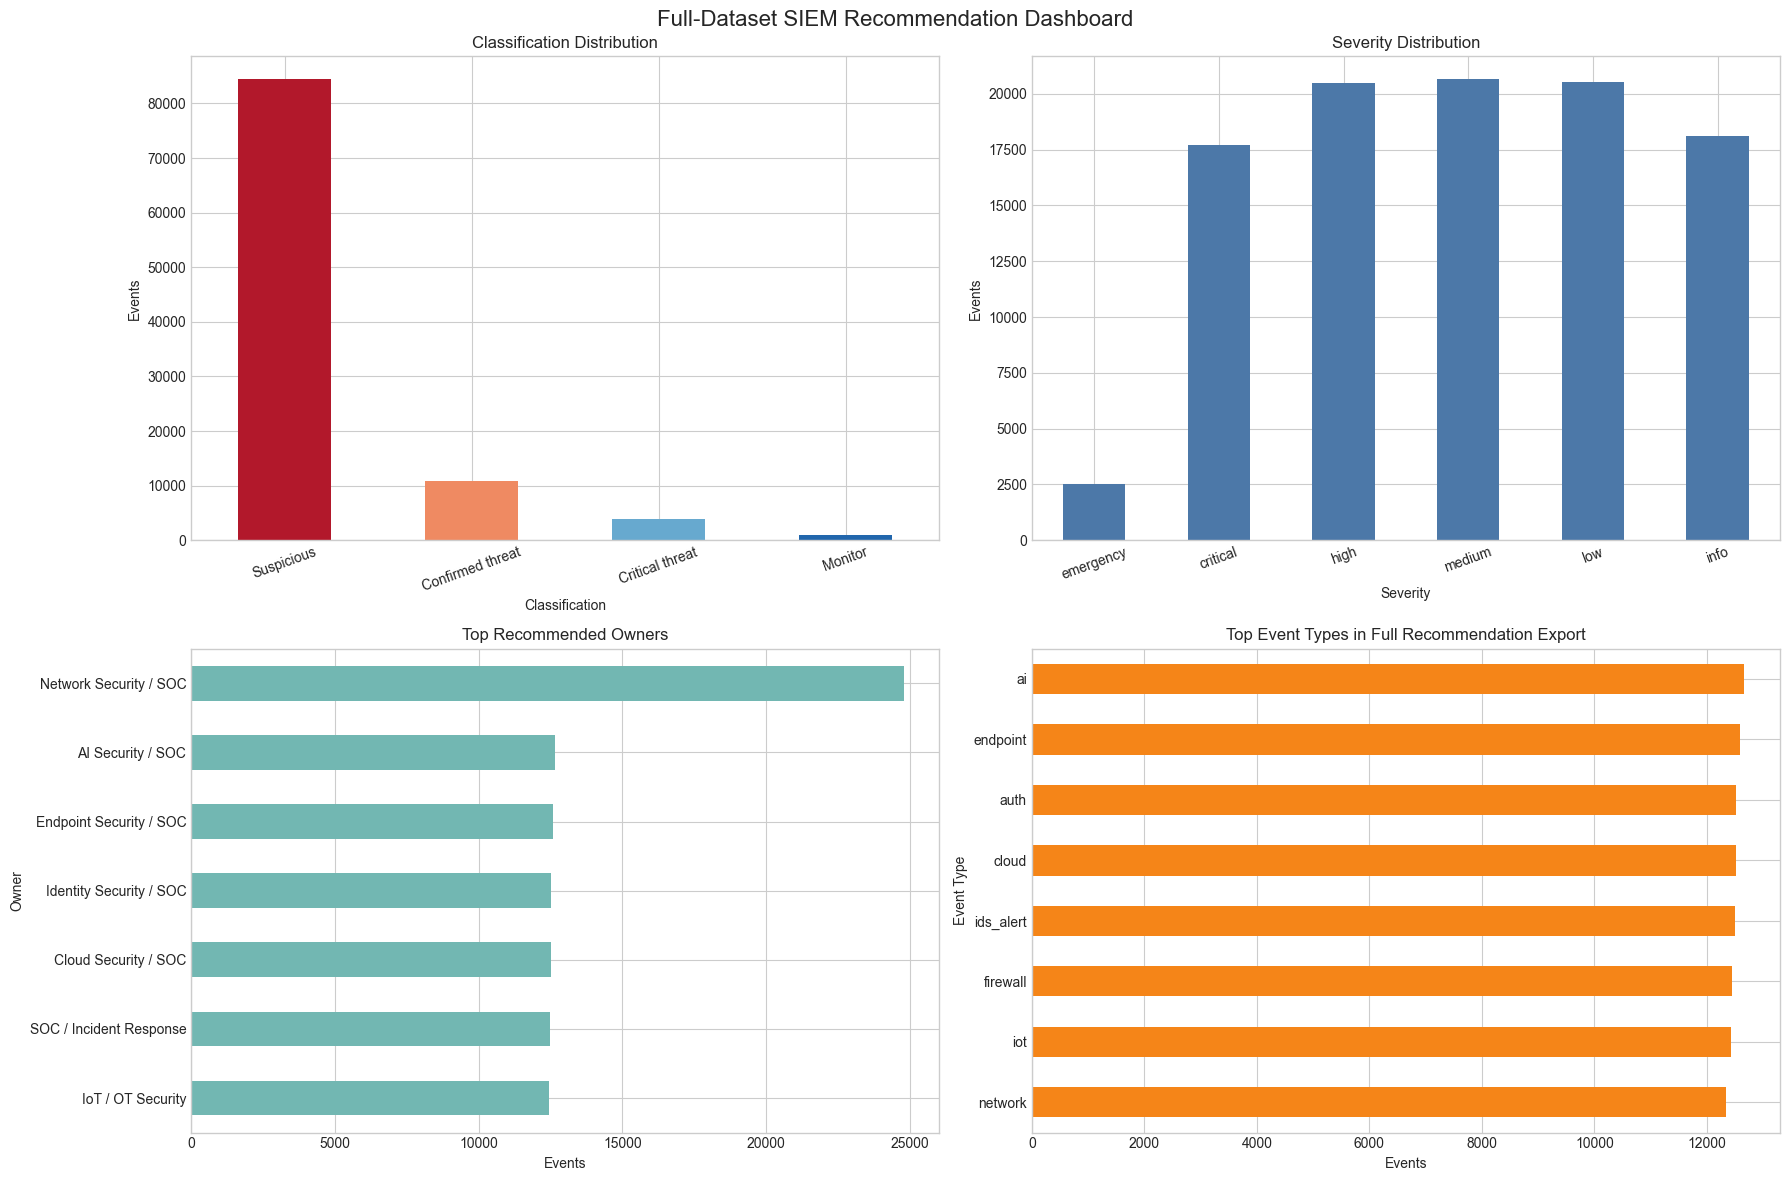

Saved dashboard to: visualizations\llm_results\all_siem_incident_recommendations_dashboard.png


In [19]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# Load the full recommendation export and build a compact dashboard for review.
# The charts focus on analyst workload: classification, severity, owners, and top event types.
full_results_source = all_case_results_path if 'all_case_results_path' in globals() else Path('llm_outputs/all_siem_incident_recommendations.csv')
full_results_df = pd.read_csv(full_results_source)
viz_dir = Path('visualizations/llm_results')
viz_dir.mkdir(parents=True, exist_ok=True)
dashboard_path = viz_dir / 'all_siem_incident_recommendations_dashboard.png'

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

classification_counts = full_results_df['classification'].value_counts()
classification_counts.plot(kind='bar', ax=axes[0, 0], color=['#b2182b', '#ef8a62', '#67a9cf', '#2166ac'])
axes[0, 0].set_title('Classification Distribution')
axes[0, 0].set_xlabel('Classification')
axes[0, 0].set_ylabel('Events')
axes[0, 0].tick_params(axis='x', rotation=20)

severity_order = ['emergency', 'critical', 'high', 'medium', 'low', 'info']
severity_counts = full_results_df['severity'].value_counts().reindex(severity_order, fill_value=0)
severity_counts.plot(kind='bar', ax=axes[0, 1], color='#4c78a8')
axes[0, 1].set_title('Severity Distribution')
axes[0, 1].set_xlabel('Severity')
axes[0, 1].set_ylabel('Events')
axes[0, 1].tick_params(axis='x', rotation=20)

owner_counts = full_results_df['recommended_owner'].value_counts().head(8).sort_values()
owner_counts.plot(kind='barh', ax=axes[1, 0], color='#72b7b2')
axes[1, 0].set_title('Top Recommended Owners')
axes[1, 0].set_xlabel('Events')
axes[1, 0].set_ylabel('Owner')

top_event_types = full_results_df['event_type'].value_counts().head(10).sort_values()
top_event_types.plot(kind='barh', ax=axes[1, 1], color='#f58518')
axes[1, 1].set_title('Top Event Types in Full Recommendation Export')
axes[1, 1].set_xlabel('Events')
axes[1, 1].set_ylabel('Event Type')

fig.suptitle('Full-Dataset SIEM Recommendation Dashboard', fontsize=16)
fig.tight_layout()
fig.savefig(dashboard_path, dpi=160, bbox_inches='tight')
plt.show()
print(f"Saved dashboard to: {dashboard_path}")


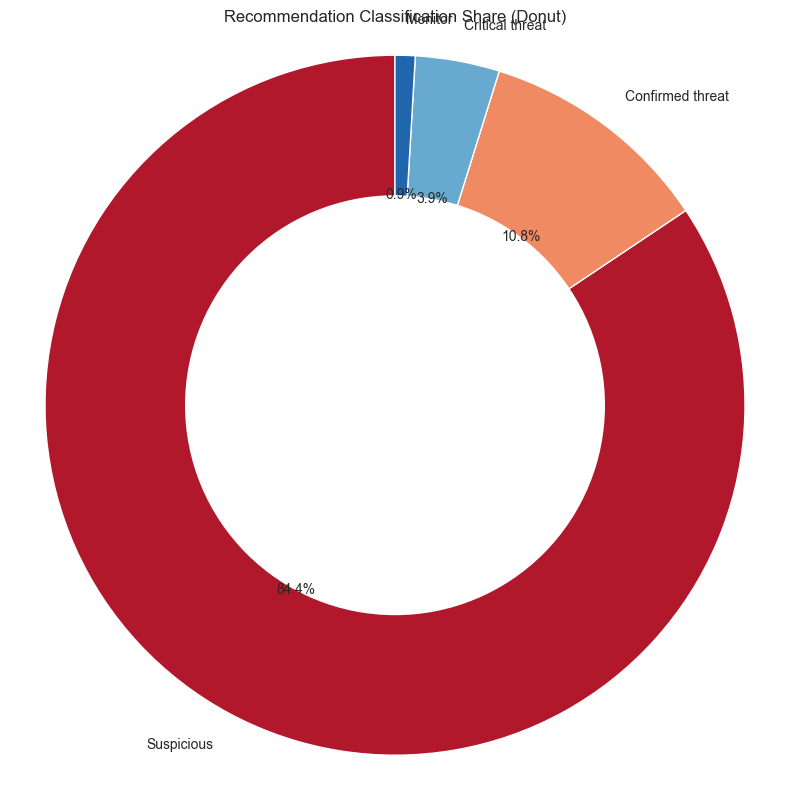

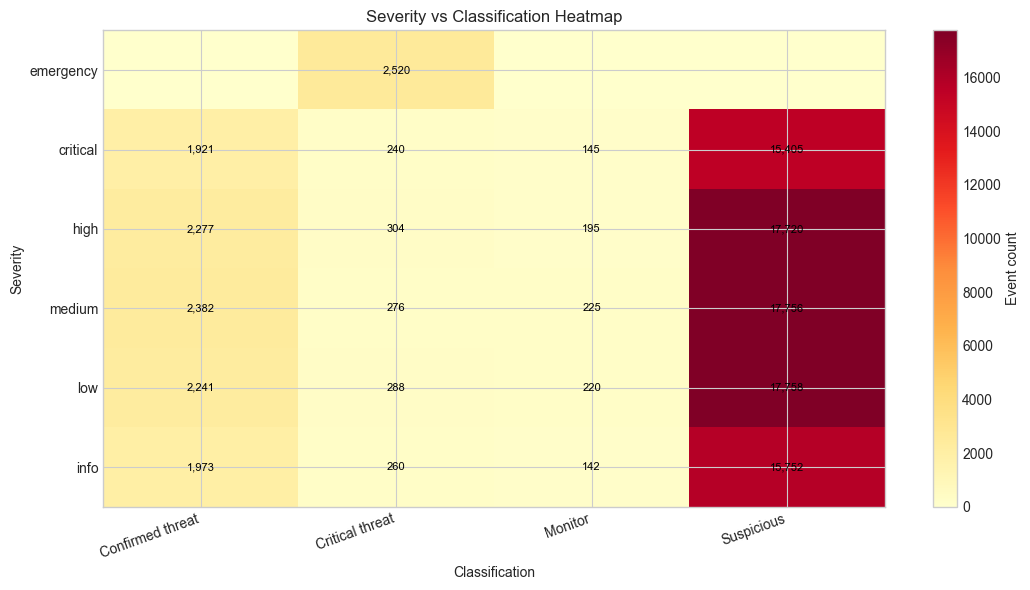

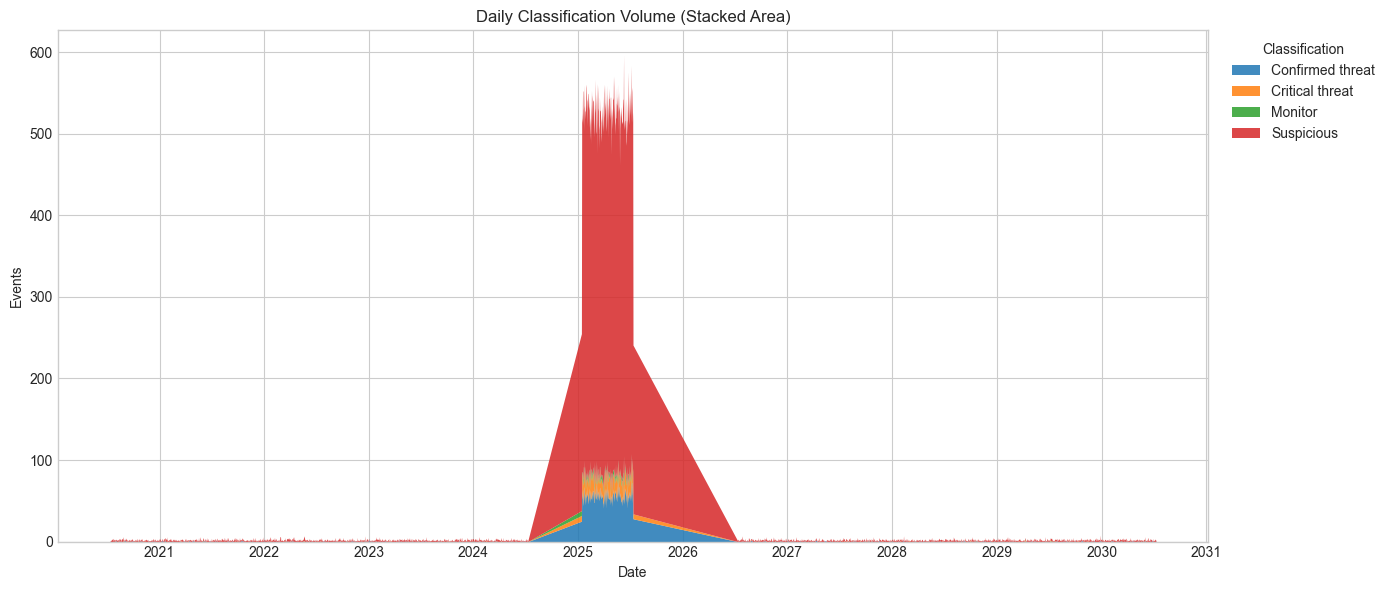

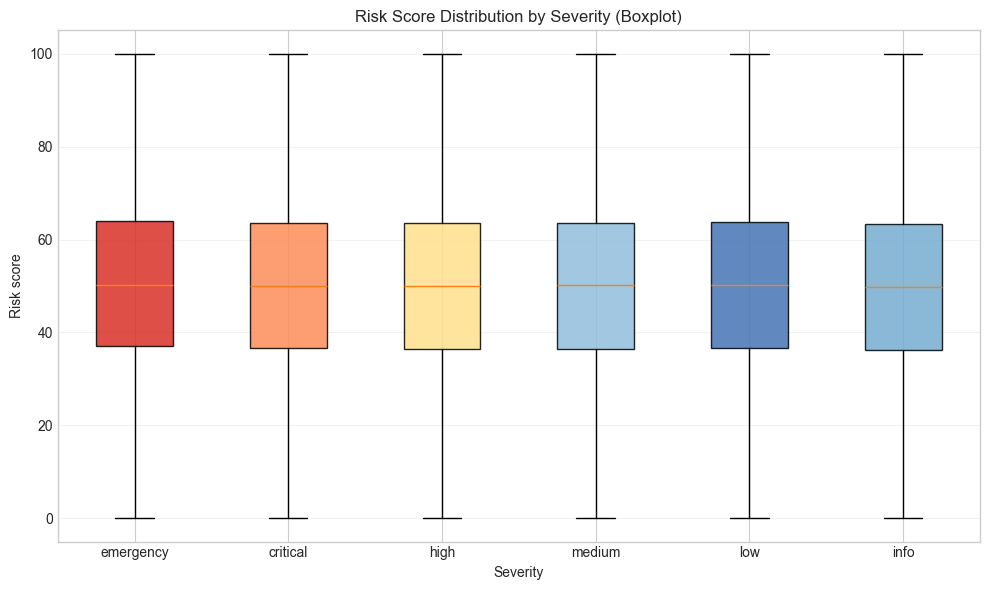

Saved additional visualizations:
- visualizations\llm_results\classification_donut.png
- visualizations\llm_results\severity_classification_heatmap.png
- visualizations\llm_results\classification_stacked_area_trend.png
- visualizations\llm_results\risk_score_by_severity_boxplot.png


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse the full recommendation dataset and create richer recommendation-focused visuals.
full_results_source = all_case_results_path if 'all_case_results_path' in globals() else Path('llm_outputs/all_siem_incident_recommendations.csv')
full_results_df = pd.read_csv(full_results_source)
viz_dir = Path('visualizations/llm_results')
viz_dir.mkdir(parents=True, exist_ok=True)

# Parse timestamp once for trend charts.
trend_df = full_results_df.copy()
trend_df['timestamp'] = pd.to_datetime(trend_df['timestamp'], errors='coerce')
trend_df = trend_df.dropna(subset=['timestamp'])

# ---------- 1) Cleaner donut chart: classification share ----------
classification_counts = full_results_df['classification'].value_counts()
donut_path = viz_dir / 'classification_donut.png'

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#b2182b', '#ef8a62', '#67a9cf', '#2166ac', '#4daf4a', '#984ea3']

wedges, _, autotexts = ax.pie(
    classification_counts.values,
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p >= 2 else '',
    pctdistance=0.76,
    startangle=90,
    colors=colors[:len(classification_counts)],
    wedgeprops={'linewidth': 1.2, 'edgecolor': 'white'}
)
for text in autotexts:
    text.set_color('#1f1f1f')
    text.set_fontsize(11)

centre_circle = plt.Circle((0, 0), 0.58, fc='white')
ax.add_artist(centre_circle)
ax.set_title('Recommendation Classification Share (Donut)', fontsize=14, pad=14)
ax.legend(
    wedges,
    [f"{label} ({count:,})" for label, count in classification_counts.items()],
    title='Classification',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)
ax.axis('equal')
fig.tight_layout()
fig.savefig(donut_path, dpi=170, bbox_inches='tight')
plt.show()

# ---------- 2) Heatmap: severity vs classification ----------
heatmap_path = viz_dir / 'severity_classification_heatmap.png'
severity_order = ['emergency', 'critical', 'high', 'medium', 'low', 'info']
severity_class_matrix = pd.crosstab(full_results_df['severity'], full_results_df['classification'])
severity_class_matrix = severity_class_matrix.reindex(severity_order, fill_value=0)

fig, ax = plt.subplots(figsize=(11, 6))
img = ax.imshow(severity_class_matrix.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(np.arange(len(severity_class_matrix.columns)))
ax.set_xticklabels(severity_class_matrix.columns, rotation=20, ha='right')
ax.set_yticks(np.arange(len(severity_class_matrix.index)))
ax.set_yticklabels(severity_class_matrix.index)
ax.set_title('Severity vs Classification Heatmap')
ax.set_xlabel('Classification')
ax.set_ylabel('Severity')

for row_idx in range(severity_class_matrix.shape[0]):
    for col_idx in range(severity_class_matrix.shape[1]):
        value = int(severity_class_matrix.iat[row_idx, col_idx])
        if value > 0:
            ax.text(col_idx, row_idx, f'{value:,}', ha='center', va='center', fontsize=8, color='black')

fig.colorbar(img, ax=ax, label='Event count')
fig.tight_layout()
fig.savefig(heatmap_path, dpi=170, bbox_inches='tight')
plt.show()

# ---------- 3) Weekly trend (cleaner than raw daily spikes) ----------
weekly_trend_path = viz_dir / 'classification_weekly_stacked_area.png'

if not trend_df.empty:
    weekly_class = (
        trend_df
        .set_index('timestamp')
        .groupby('classification')
        .resample('W')
        .size()
        .unstack(0, fill_value=0)
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=(14, 6))
    if not weekly_class.empty:
        weekly_class.plot.area(ax=ax, alpha=0.88, linewidth=0)
        ax.set_title('Weekly Recommendation Volume by Classification (Stacked Area)')
        ax.set_xlabel('Week')
        ax.set_ylabel('Events')
        ax.legend(title='Classification', loc='upper left', bbox_to_anchor=(1.01, 1.0))
    else:
        ax.text(0.5, 0.5, 'No weekly trend data available', ha='center', va='center')
        ax.set_axis_off()

    fig.tight_layout()
    fig.savefig(weekly_trend_path, dpi=170, bbox_inches='tight')
    plt.show()
else:
    weekly_trend_path = None

# ---------- 4) Recommendation owner vs classification (stacked bar) ----------
owner_mix_path = viz_dir / 'owner_classification_stacked_bar.png'
owner_class = pd.crosstab(full_results_df['recommended_owner'], full_results_df['classification'])
owner_class = owner_class.loc[owner_class.sum(axis=1).sort_values(ascending=False).head(10).index]
owner_class_pct = owner_class.div(owner_class.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))
owner_class_pct.plot(kind='barh', stacked=True, ax=ax, colormap='tab20c')
ax.set_title('Top Owners: Classification Mix (% of Owner Workload)')
ax.set_xlabel('Percentage of owner workload')
ax.set_ylabel('Recommended owner')
ax.legend(title='Classification', loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
fig.savefig(owner_mix_path, dpi=170, bbox_inches='tight')
plt.show()

# ---------- 5) Risk score by severity (violin plot) ----------
risk_violin_path = viz_dir / 'risk_score_by_severity_violin.png'
fig, ax = plt.subplots(figsize=(10, 6))

if 'risk_score' in full_results_df.columns:
    risk_df = full_results_df.copy()
    risk_df['risk_score'] = pd.to_numeric(risk_df['risk_score'], errors='coerce')
    risk_df = risk_df.dropna(subset=['risk_score'])

    plot_groups = []
    labels = []
    for sev in severity_order:
        vals = risk_df.loc[risk_df['severity'] == sev, 'risk_score'].values
        if len(vals) > 0:
            plot_groups.append(vals)
            labels.append(sev)

    if plot_groups:
        vp = ax.violinplot(plot_groups, showmeans=True, showmedians=True)
        for body in vp['bodies']:
            body.set_alpha(0.65)
        ax.set_xticks(range(1, len(labels) + 1))
        ax.set_xticklabels(labels)
        ax.set_title('Risk Score Distribution by Severity (Violin)')
        ax.set_xlabel('Severity')
        ax.set_ylabel('Risk score')
        ax.grid(axis='y', alpha=0.25)
    else:
        ax.text(0.5, 0.5, 'Risk score data is empty after cleaning', ha='center', va='center')
        ax.set_axis_off()
else:
    ax.text(0.5, 0.5, 'Column risk_score not found in full recommendation export', ha='center', va='center')
    ax.set_axis_off()

fig.tight_layout()
fig.savefig(risk_violin_path, dpi=170, bbox_inches='tight')
plt.show()

# ---------- 6) Optional interactive recommendation dashboard (Plotly HTML) ----------
interactive_html_path = viz_dir / 'recommendation_interactive_dashboard.html'
try:
    import plotly.express as px
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go

    monthly_class = (
        trend_df
        .set_index('timestamp')
        .groupby('classification')
        .resample('MS')
        .size()
        .unstack(0, fill_value=0)
        .sort_index()
        .reset_index()
    )

    fig_int = make_subplots(
        rows=1,
        cols=2,
        specs=[[{'type': 'domain'}, {'type': 'xy'}]],
        subplot_titles=('Classification Share', 'Monthly Recommendation Trend')
    )

    pie = px.pie(
        values=classification_counts.values,
        names=classification_counts.index,
        hole=0.55
    )
    for trace in pie.data:
        fig_int.add_trace(trace, row=1, col=1)

    for cls in [c for c in monthly_class.columns if c != 'timestamp']:
        fig_int.add_trace(
            go.Scatter(
                x=monthly_class['timestamp'],
                y=monthly_class[cls],
                mode='lines+markers',
                name=str(cls)
            ),
            row=1,
            col=2
        )

    fig_int.update_layout(height=520, width=1200, title_text='Interactive Recommendation Dashboard')
    fig_int.write_html(str(interactive_html_path), include_plotlyjs='cdn')
    interactive_status = f'Saved interactive dashboard: {interactive_html_path}'
except Exception as ex:
    interactive_status = f'Interactive dashboard skipped ({type(ex).__name__}: {ex})'

print('Saved additional recommendation visualizations:')
print(f'- {donut_path}')
print(f'- {heatmap_path}')
if weekly_trend_path:
    print(f'- {weekly_trend_path}')
print(f'- {owner_mix_path}')
print(f'- {risk_violin_path}')
print(f'- {interactive_status}')